# Flujo y transporte reactivo de 2 especies en equilibrio con el yeso en 1D. 

**Descripción**.

En esta notebook se modela el flujo y transporte reactivo de la componente $U = c_1 - c_2$ donde $c_1 = SO_4^{2-}$ y $c_2 = Ca^{2+}$. La estrategia de solución consiste en resolver el flujo con GWF, discretizar el transporte con DFC para generar las matrices de coeficientes, calcular las razones de mezcla ($\lambda$'s) y finalmente resolver el transporte reactivo con WMA.

<a href="https://github.com/luiggix/RTWMA">RTWMA</a> © 2024-2026 by <a href="https://www.geofisica.unam.mx">IGF-UNAM</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc/4.0/">CC BY-NC 4.0</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">

# Planteamiento del problema.

El dominio es una columna 1D de longitud $L = 30 \text{ (m)}$, en dirección $x$, representando un acuífero de espesor y ancho unitarios, véase figura 1. 

<figure>
  <img src="../../figures/U_transporte.svg" width=600px alt="dominio de estudio y condiciones" />
  <figcaption>Figura 1. Dominio de estudio, condiciones iniciales y de frontera. El dominio es de tamaño $L = 30 \text{ (m)}$ y será dividido en $30$ celdas de $1\;\text{(m)}$ cada una de tal manera que $x_{_{12}}$ va del inicio del dominio al centro de la celda número $12$. </figcaption>
</figure>

Sobre este dominio ocurren los siguientes procesos:

- Flujo de agua subterránea, gobernado por la carga hidráulica $h(x,t)$.
- Transporte reactivo, gobernado por un conjunto de ecuaciones que expresan el balance de masa de las especies químicas y las reacciones químicas. 

El problema se va a resolver en un periodo de $40$ días, con un paso de tiempo constante de $1$ día ($40$ pasos de tiempo).

# Estrategia de solución.

En la figura 2 se muestra el proceso de solución de este problema. Obsérvese que se utilizan diferentes programas para cada proceso, los cuales generan información que se guarda en archivos e información que se genera en memoria. Los programas que implementan cada paso están escritos Python y/o en Fortran.

<figure>
  <img src="../../figures/gwf_dfc_wma.svg" width=700px alt="dominio de estudio y condiciones" />
  <figcaption>

Figura 2. El flujo se resuelve usando GWF a través de FloPy, los datos se proporcionan en diccionarios de Python (`dis`, `tdis`, `phys`, entre otros). GWF genera archivos de salida con los resultados del flujo (`.hds`, `.bud`). Esta información es utilizada por DFC para generar los coeficientes de la discretización del modelo de transporte, dichos coeficientes se generan en memoria. El módulo `Lambdas` calcula las proporciones de mezcla ($\lambda$'s) y las almacena en archivos (`.dat`). Finalmente, el ejecutable **TR_1D_oper.exe** realiza los cálculos de transporte reactivo usando las proporciones de mezcla y envía los resultados a archivos (`.out`). En esta última etapa se realizan todos los pasos de tiempo del problema de transporte reactivo para un flujo estacionario.

</figcaption>
</figure>

# Modelo de flujo de agua subterránea.

Para un acuífero 1D, confinado, con conductividad hidráulica $K_x$ y
coeficiente de almacenamiento específico $S_s$, la ecuación de flujo es:

$$
S_s \frac{\partial h}{\partial t} = \frac{\partial}{\partial x}
\left( K_x \frac{\partial h}{\partial x} \right) + q_s(x,t)
$$

donde $q_s(x,t)$ representa fuentes o sumideros volumétricos de agua por
unidad de volumen (p. ej. un pozo).

**Condiciones de frontera:**

$$
\left.\frac{\partial h}{\partial x}\right|_{(0,t)} = 0
\qquad\text{(frontera cerrada / flujo nulo en } x=0\text{)}
$$

$$
h(x_{_{L}}, t) = 1.0 \qquad\text{(carga fija en el extremo } x=x_{_{L}}\text{)}
$$

**Condición inicial:** 

$$
h(x,t_0) = 1.0 \qquad\text{(m)}
$$

## Solución numérica del flujo con GWF.

La solución numérica se obtiene usando el modelo GWF de MODFLOW 6 en conjunción con FloPy, a continuación se describen los pasos más importantes de la implementación.

In [14]:
import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy
import xmf6
from gypsum import gwf, lambdas, wma
linea = 50*chr(0x2015)

### Discretización espacial.

<figure>
  <img src="../../figures/spatial_dis.svg" width=600px alt="dominio de estudio y condiciones" />
  <figcaption>Figura 4. El espacio se discretiza en 30 celdas. Se resaltan las celdas de la frontera y aquellas donde se tiene una condición inicial de concentración alta. </figcaption>
</figure>

|Parámetro | Valor | Unidades | Variable |
|---:|:---:|:---:|:---|
|Length of system (rows) | $30.0$ | m | |
|Number of layers | $1$ | | `dis["nlay"]`|
|Number of rows | $1$ | | `dis["nrow"]`|
|Number of columns | $30$ | | `dis["ncol"]`|
|Column width | $1.0$ | m | `dis["delr"]`|
|Row width | $1.0$ | m | `dis["delc"]`|
|Top of the model | $1.0$ | m | `dis["top"]`|
|Layer bottom elevation (cm) | $0$ | m | `dis["botm"]`|

In [2]:
# Discretización espacial
nlay = 1
nrow = 1
ncol = 30
delr = 1.0
delc = 1.0
top  = 1.0
botm = 0.0

dis = {
    'units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : top, 
    'botm': botm 
}
xmf6.nice_print(dis, "Spatial discretization")


Spatial discretization
――――――――――――――――――――――
units = meters
 nlay = 1
 nrow = 1
 ncol = 30
 delr = 1.0
 delc = 1.0
  top = 1.0
 botm = 0.0
――――――――――――――――――――――


### Discretización del tiempo.

El problema se resuelve en un periodo de $40$ días con un paso de tiempo constante de $1$ día ($40$ pasos de tiempo). Sin embargo, debido a que el flujo se mantiene constante durante toda la simulación, se utiliza un solo paso de tiempo de $40$ días para resolver el flujo. 

|Parámetro | Valor| Unidades | Variable |
|---:|:---:|:---:|:---|
|Number of stress periods (NPER) | $1$ | | `tdis["nper"]` |
|Total time | $40$ | days | `tdis["perioddata"][0][0]` |
|Number of time steps (NSTP) | $1$ | | `tdis["perioddata"][0][1]` |
|Multiplier (TSMULT)| $1$ | | `tdis["perioddata"][0][2]` |
    

<div class="alert alert-info">
    
**NOTA**.

El valor del parámetro NSTP será cambiado a $40$ cuando se resuelva el transporte reactivo.
</div>

In [3]:
# Discretización del tiempo para el flujo 
tdis = {
    'units': "days",
    'nper' : 1,
    'perioddata': [(40.0, 1, 1.0)] #PERLEN, NSTP, TSMULT
}
xmf6.nice_print(tdis, "Time discretization (flow)")


Time discretization (flow)
――――――――――――――――――――――――――
     units = days
      nper = 1
perioddata = ―― data array ――
           = (40.0, 1, 1.0)
――――――――――――――――――――――――――


### Parámetros físicos.

Los parámetros necesarios para esta simulación se muestran en la siguiente tabla.

|Parámetro | Símbolo | Valor | Unidades | Variable |
|---:|:--:|:---:|:---:|:---|
|Initial head | $h(x, t_0)$| $1.0$ | m | `phys["initial_head"]` |
|Head boundary condition (type I) | $h({x_{_{L}}, t})$ | 1.0 | m | `phys["bc_head_t1"]` |
|Hydraulic conductivity | $K_x$ |$1.0$| m d$^{-1}$ | `phys["hydraulic_conductivity"]` |
|Specific discharge | $q_s$ |$0.2$| m d$^{-1}$ | `phys["specific_discharge"]` |
|Source concentration | $U_s$ | -- | unitless | `phys["source_concentration"][0]` |
|Well inyection | $q_s U_s$ | -- | m d$^{-1}$ | `phys["well"]`|
|Porosity | $\theta$ | $0.5$ | unitless |  `phys["porosity"]` |
|Initial concentration | $U(x, t_0)$ | -- | unitless | `phys["initial_concentration"]` |
|Initial concentration pulse | $U(x_{_{12}}, t_0)$ | -- | unitless | `phys["initial_concentration"][11]` |
|Concentration boundary condition (type I) | $U(x_{_{1}}, t)$ | -- | unitless | `phys["bc_conc_t1"][0]` |
|Longitudinal Dispersivity | $\alpha_L$ |$0.2$ | m  | `phys["longitudinal_dispersivity"]` |
|Dispersion coefficient | $D_{xx}$ | $0.2$ | m$^{2}$ d$^{-1}$| `phys["dispersion_coefficient"]` |

donde:

* $U_s = c_{s1} - c_{s2}$
* $U(x, t_0) = c_1(x, t_0)-c_2(x, t_0)$
* $U(x_{_{12}}, t_0) = c_1(x_{_{12}}, t_0)-c_2(x_{_{12}}, t_0)$
* $U(x_{_{1}}, t) = c_1(x_{_{1}}, t)-c_2(x_{_{1}}, t)$

In [4]:
# Arreglo para la condición inicial de c1
c1_ini = np.full((nlay,nrow,ncol), 1.0000329) # En todo el dominio
c1_ini[0, 0, 11] = 200.0  # Pulso en x_L

# Arreglo para la condición inicial de c2
c2_ini = np.full((nlay,nrow,ncol), 3.294e-5) # En todo el dominio
c2_ini[0, 0, 11] = 1.647e-7  # Pulso en x_L

# Arreglo para la condición inicial de U
U_ini = c1_ini - c2_ini # En todo el dominio
U_ini[0, 0, 11] = c1_ini[0, 0, 11] - c2_ini[0, 0, 11]  # Pulso en x_L
print("Array info: U")
xmf6.info_array(U_ini)

U_s = c1_ini[0, 0, 0] - c2_ini[0, 0, 0]

phys = dict(
    initial_head = 1.0,
    bc_head_t1 = [("CHD-1" , [(0, 0, dis['ncol'] - 1), 1.0])],
    hydraulic_conductivity = 1.0, 
    specific_discharge = 0.2, 
    source_concentration = U_s,
    porosity = 0.5,
    initial_concentration = U_ini,
    bc_conc_t1 = [("CNC-1", [(0, 0, 0), U_s])],
    longitudinal_dispersivity = 0.2,
    dispersion_coefficient = 0.2,
    decay_rate =  0.0,
)
# Agregamos la información del pozo
q = phys["specific_discharge"] * dis['delc'] * dis['delr'] * dis['top']
phys["well"] = [("WEL-1", "AUX", "CONCENTRATION"), ((0, 0, 0), q, phys["source_concentration"])]

xmf6.nice_print(phys, "Physical parameters")

Array info: U
 tipo  : <class 'numpy.ndarray'> 
 dtype : float64 
 dim   : 3 
 shape : (1, 1, 30) 
 size(bytes) : 8 
 size(elements) : 30

Physical parameters
―――――――――――――――――――
             initial_head = 1.0
               bc_head_t1 = ―― data array ――
                          = ('CHD-1', [(0, 0, 29), 1.0])
   hydraulic_conductivity = 1.0
       specific_discharge = 0.2
     source_concentration = 0.9999999599999999
                 porosity = 0.5
    initial_concentration = ―― data array ――
                          = [[  0.99999996   0.99999996   0.99999996   0.99999996   0.99999996
    0.99999996   0.99999996   0.99999996   0.99999996   0.99999996
    0.99999996 199.99999984   0.99999996   0.99999996   0.99999996
    0.99999996   0.99999996   0.99999996   0.99999996   0.99999996
    0.99999996   0.99999996   0.99999996   0.99999996   0.99999996
    0.99999996   0.99999996   0.99999996   0.99999996   0.99999996]]
               bc_conc_t1 = ―― data array ――
                      

### Rutas, nombres de archivos y otros.

Definimos un diccionario con información de las rutas ejecutables, directorios de trabajo, archivos de salida y entrada, y nombres de modelos.

In [5]:
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",  
    #
    # Directorio de trabajo para WMA
    wma_working_dir = r"C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE",
    #
    # Archivo de salida de "TR_1D_oper.exe"
    gypsum_eq_dfc = 'gypsum_eq_dfc.out',
    excel_data = 'comparativa_02.xlsx',
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "output_gwf_dfc_wma",
)
#
# Ejecutable "TR_1D_oper.exe"
paths["tr1d_exe"] = os.path.join(paths["wma_working_dir"], "TR_1D_oper.exe")
#
# Archivo para almacenar las proporciones de mezcla 
paths["wma_lambdas_filename"] = os.path.join(paths["wma_working_dir"], 
                                             "input", "gypsum_eq", 
                                             "WMA_lambdas_gypsum_eq.dat")
#
# Archivo de resultados del transporte reactivo
paths["gypsum_eq"] = os.path.join(paths["wma_working_dir"], 'gypsum_eq.out')
#
# Archivo requerido por "TR_1D_oper.exe"
paths["wma_workingDirectory_file"] = os.path.join(paths["wma_working_dir"], "workingDirectory.txt")
    
xmf6.nice_print(paths, "Rutas y nombres de archivos")


Rutas y nombres de archivos
―――――――――――――――――――――――――――
                  mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
                  mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
          wma_working_dir = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE
            gypsum_eq_dfc = gypsum_eq_dfc.out
               excel_data = comparativa_02.xlsx
                flow_name = flow
                  flow_ws = output_gwf_dfc_wma
                 tr1d_exe = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\TR_1D_oper.exe
     wma_lambdas_filename = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\input\gypsum_eq\WMA_lambdas_gypsum_eq.dat
                gypsum_eq = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\gypsum_eq.out
wma_workingDirectory_file = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\workingDirectory.txt
――――――――――――――――

### Construcción y ejecución del modelo de flujo con GWF.

Para resolver el problema de flujo requerimos de los siguientes paquetes:

- `DIS`: Discretización espacial de tipo estructurada.
- `NPF`: Propiedades del flujo, particularmente la conductividad hidráulica $K_x$.
- `IC`: Definición de las condiciones iniciales de la carga hidráulica.
- `CHD`: Condición de frontera de carga hidráulica fija $h(x_{_{L}},t)=1.0$.
- `WEL`: Pozo de inyección de $q_s U_s$ en $x_{_{1}}$.
- `OC` : Definición de los archivos para almacenar los resultados de la simulación.
- No se define el paquete `STO` debido a que el flujo se resuelve en régimen
  permanente.
- El límite izquierdo ($x=0$) no recibe ninguna condición de frontera, por
  lo que MODFLOW 6 le asigna flujo nulo por defecto:
  $\partial h/\partial x(0,t)=0$ se cumple automáticamente.

La implementación se encuentra en la función `build()` en el archivo [**gwf_dfc.py**](gwf_dfc.py).

In [6]:
print(linea)
print("Escritura de archivos de entrada para GWF.")
print(linea)

# Escritura de los archivos de entrada para la simulación de flujo.
o_sim, o_gwf = gwf.build(paths, tdis, phys, dis, silent = False) 

print(linea)
print("Ejecución de GWF.")
print(linea)

# Ejecución de la simulación de flujo.
o_sim.run_simulation(silent = False)

――――――――――――――――――――――――――――――――――――――――――――――――――
Escritura de archivos de entrada para GWF.
――――――――――――――――――――――――――――――――――――――――――――――――――
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package chd-1...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 1 based on size of stress_period_data
    writing package wel-1...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
――――――――――――――――――――――――――――――――――――――――――――――――――
Ejecución de GWF.
――――――――――――――――――――――――――――――――――――――――――――――――――
FloPy is using the following executable to run the model: ..\..\..\..\..\mf6_tutorial\mf6\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOG

(True, [])

### Análisis de los resultados.

In [7]:
# Objeto para acceder a los resultados de la carga hidráulica.
o_head = o_gwf.output.head()

# Tiempos calculados para el flujo.
times_h = np.array(o_head.get_times())

# Recuperamos la carga hidráulica del paso 40.
head = o_head.get_data(totim=40)[0, 0, :]

# Recuperamos la descarga específica del paso 40.
budget = o_gwf.output.budget()
spdis = budget.get_data(totim=40, text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, o_gwf)

# Recuperamos las coordenadas del dominio
grid = o_gwf.modelgrid

# Recuperamos las coordenadas de los centros de las celdas de la malla
x = grid.xcellcenters[0] # centros de los volúmenes

flow_data = dict(
    xcoord = [x],
    times_h = [times_h],
    head = [head],
    qx = qx[:,0],
)
xmf6.nice_print(flow_data, "Head")


Head
――――
 xcoord = ―― data array ――
        = [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
times_h = ―― data array ――
        = [40.]
   head = ―― data array ――
        = [6.8 6.6 6.4 6.2 6.  5.8 5.6 5.4 5.2 5.  4.8 4.6 4.4 4.2 4.  3.8 3.6 3.4
 3.2 3.  2.8 2.6 2.4 2.2 2.  1.8 1.6 1.4 1.2 1. ]
     qx = ―― data array ――
        = [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
――――


# Modelo de transporte reactivo.

El transporte reactivo está gobernado por un conjunto de ecuaciones que expresan el balance de masa de las especies químicas y las reacciones químicas. La ecuación de transporte advectivo se escribe como sigue:

$$
\phi \frac{\partial \mathbf{c}}{\partial t} = - \mathbf{q} \cdot \nabla \mathbf{c} + \nabla \cdot \left( \mathbf{D}  \nabla \mathbf{c} \right) + r \left( \mathbf{c}_{r} - \mathbf{c} \right) + \phi \mathbf{r}
$$

donde $\phi \in (0,1]$ es la porosidad; $\mathbf{c} \in \mathbb{R}^{N_{sp}}$ es el vector de concentración de todas las especies; 
$\mathbf{q}$ es la descarga específica; $\mathbf{D}$ es el tensor de dispersión; $r$ es el término fuente/sumidero de agua, con concentración $\mathbf{c}_{r}$ si $r > 0$ (recarga), o, $\mathbf{c}_{r} = \mathbf{c}$ si $r < 0$ (descarga), o $\mathbf{c}_{r} = 0$ cuando $r < 0$ representa evaporación; $\mathbf{r}$ es la contribución de las reacciones químicas al balance de masas de las especies (por unidad de tiempo). Esta ecuación debe resolverse bajo condiciones iniciales apropiadas:

$$
\mathbf{c}(\mathbf{x},0) = \mathbf{c}_0
$$ 

y condiciones de contorno, que escribimos como:

$$
\left( \mathbf{q} \mathbf{c} - \mathbf{D} \nabla \mathbf{c} \right) \cdot \mathbf{n} = \mathbf{q}_{_{BC}} \mathbf{c}_{_{BC}}. 
$$

donde $\mathbf{q}_{_{BC}}$ y  $\mathbf{c}_{_{BC}}$ son valores que se dan en la frontera del dominio.

Para dos especies, $c_1$ y $c_2$, en una dimensión, las ecuaciones de transporte advectivo se escriben como sigue:

$$
\begin{equation}
\phi \frac{\partial c_1}{\partial t} = -q_{x}\frac{\partial c_1}{\partial x }+D_{xx}\frac{\partial^{2} c_1}{\partial x^{2}}+r(c_{1,r}-c_1)+R_1
\end{equation}
$$

$$
\begin{equation}
\phi \frac{\partial c_2}{\partial t} = -q_{x}\frac{\partial c_2}{\partial x }+D_{xx}\frac{\partial^{2} c_2}{\partial x^{2}}+r(c_{2,r}-c_2)+R_1
\end{equation}
$$

Restando las dos ecuaciones anteriores se obtiene:

$$
\begin{equation}
\phi \frac{\partial U}{\partial t} = -q_{x}\frac{\partial U}{\partial x }+D_{xx}\frac{\partial^{2} U}{\partial x^{2}}+r(U_{r}-U) \tag{1}
\end{equation}
$$

donde $U=c_1-c_2$.

## Condiciones iniciales.

$$U_{_{i}} = c_{1_{i}} - c_{2_{i}} \approx 1.0, \; \text{para} \; i \neq 12$$
$$U_{_{12}} = c_{1_{12}} - c_{2_{12}} \approx 199.999967$$

## Condiciones de frontera.

$$\textcolor{red}{U_{_{1}} = c_{1_{1}} - c_{2_{1}} \approx 1.0, \; \text{para} \; x = 0 \; (\text{m})}$$ 
$$\left[qU-D_{xx}\frac{\partial U}{\partial x}\right]_{i=1} = q_{\text{inf}} U_{\text{inf}}, \; \text{para} \; x = 0 \; (\text{m})$$
$$D_{xx} \dfrac{dU}{dx}\Big|_{_{\text{ncol}}} = 0, \; \text{para} \; x = 30 \; (\text{m})$$


## Discretización con diferencias finitas centrales.

Discretizamos la ecuación $(1)$ usando diferencias finitas centrales:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  \bigg( - q_{x}|_{i+1/2} \frac{U_{i+1}-U_{i}}{2 \Delta x} - q_{x}|_{i-1/2} \frac{U_{i}-U_{i-1} }{2 \Delta x} \bigg ) + D_{xx} \frac{U_{i+1}-2U_{i}+U_{i-1}}{\Delta x^{2}}+r_{i}(U_{r}|_{i}-U_{i})
\end{equation}
$$


<div class="alert alert-info">

**NOTA**.

Se usan los superíndices $n+1$ y $n$ para indicar el paso de tiempo, con el fin de usar los índices $i,j,k$ para los índices espaciales en tres dimensiones.
</div>

Reacomodando términos:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  \bigg( \frac{ q_{x}|_{i-1/2}}{ 2 \Delta x}+\frac{D_{xx}}{\Delta x^{2}} \bigg ) U_{i-1}+\bigg(\frac{q_{x}|_{i+1/2}}{ 2 \Delta x}-\frac{ q_{x}|_{i-1/2}}{ 2 \Delta x} - \frac{2 D_{xx}}{\Delta x^{2}}-r_{i}  \bigg) U_{i}+ \bigg(   -\frac{q_{x}|_{i+1/2}}{ 2 \Delta x}+\frac{D_{xx}}{\Delta x^{2}} \bigg) U_{i+1}+r_{i} U_{r}|_{i} 
\end{equation}
$$

Reescribiendo la ecuación se tiene la siguiente ecuación general:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  T_{W} U_{i-1}+ T_{C} U_{i}+ T_{E} U_{i+1}+r_{i} U_{r}|_{i}  \tag{2}
\end{equation}
$$

donde

* $T_{W}$ transmisibilidad oeste (*West*),
* $T_{C}$ transmisibilidad central (*Center*),
* $T_{E}$ transmisibilidad este (*East*),

### Condiciones de frontera numéricas.

La ecuación $(2)$ solo es válida para las celdas internas, falta aplicarla para las celdas en las fronteras. 

**Robin.**

Considerando una condición tipo Robin del lado izquierdo se tiene:

$$
\begin{equation}
\left[qU-D_{xx}\frac{\partial U}{\partial x}\right]_{i=1} = q_{\text{inf}} U_{\text{inf}}
\end{equation}
$$

Aplicando la técnica de celda fantasma, discretizando mediante diferencias finitas hacia atrás, ya que se requiere relacionar la celda del dominio con la celda fantasma:

$$
\begin{eqnarray}
q_{i}U_{i}-D_{xx}\frac{U_{i}-U_{i-1}}{\Delta x} = q_{\text{inf}} U_{\text{inf}}\\
\\
U_{i-1}=\frac{(q_{\text{inf}} U_{\text{inf}}) \Delta x}{D_{xx}}-\frac{(q_{i}U_{i}) \Delta x}{D_{xx}}+U_{i}\\
\\
U_{i-1}=\frac{(q_{\text{inf}} U_{\text{inf}}) \Delta x}{D_{xx}}+\bigg(1-\frac{(q_{i}) \Delta x}{D_{xx}} \bigg) U_{i}\\
\\
U_{i-1}= A U_{\text{inf}} +(1-B) U_{i}\\
\end{eqnarray}
$$

donde $A = q_{\text{inf}} \Delta x / D_{xx}$ y $B = q_{i} \Delta x / D_{xx}$. Para el caso donde la carga específica $q_{\text{inf}}=q_{i}$, se tiene $A=B$. 

Sustituyendo $U_{i-1}$ en la ecuación general:

$$
\begin{eqnarray}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  T_{W}[A U_{\text{inf}} +(1-B) U_{i}] + T_{C} U_{i}+ T_{E} U_{i+1}+r_{i} U_{r}|_{i} \\
\\
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =   (1-B+T_{C}) U_{i} + T_{E} U_{i+1}+r_{i} U_{r}|_{i} +T_{W} A U_{inf}\\
\end{eqnarray}
$$

Note que esta ecuación solo es válida para la primera celda donde está la condición a la frontera. 

**Neumann.**

Considerando la salida, que es la última celda, se tiene la siguiente condición de frontera Neumann:

$$
\begin{equation}
\left[D_{xx}\frac{\partial U}{\partial x}\right]_{i=\text{ncol}} = 0
\end{equation}
$$

Lo que significa que la variable $U$ se mantiene constante en la dirección $x$, discretizando y despejando para la celda fantasma $U_{i+1}$ :

$$
\begin{eqnarray}
D_{xx}\frac{\partial U}{\partial x} = 0 \quad \rightarrow \quad   D_{xx} \frac{U_{i+1}-U_{i}}{\Delta x} = 0 \quad \rightarrow \quad   U_{i+1}=U_{i}
\end{eqnarray}
$$

Sustituyendo en la ecuación general:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  T_{W} U_{i-1}+ (T_{C}+T_{E}) U_{i}+r_{i} U_{r}|_{i}  
\end{equation}
$$

## Notación matricial.

Tomando en cuenta todo el proceso algebraico anterior, la discretización del problema se puede escribir de forma matricial como:

$$
\begin{equation}
\boldsymbol{D} \frac{\boldsymbol{U}^{n+1}-\boldsymbol{U}^{n}}{\Delta t} = \boldsymbol{A}\boldsymbol{U}+\boldsymbol{R} \boldsymbol{U_{r}} + \boldsymbol{Q} \boldsymbol{U_{\text{inf}}} \tag{3}
\end{equation}
$$

donde 

* $\boldsymbol{D}$ es una matriz diagonal que incluye la porosidad del sistema $\phi$ ,
* $\boldsymbol{A}$ es una matriz tridiagonal que contiene las transmibilidades del dominio incluyendo las condiciones de frontera,
* $\boldsymbol{R}$ es una matriz diagonal y sus valores están ligados con las celdas donde existe recarga,
* $\boldsymbol{Q}$ es también una matriz diagonal, que para este caso tiene un único valor correspondiente a la frontera de infiltración.

Nótese que todas las matrices son de tamaño $n_x \times n_x$ y los vectores de tamaño $n_x$, con $n_x$ el número de celdas en la dirección $x$. Se debe tener en cuenta que $\boldsymbol{U_{r}}$ y $\boldsymbol{U_{\text{inf}}}$ solo tendrán valores diferentes de cero en la diagonal principal en ciertas partes donde el problema así lo requiere. En este caso $\boldsymbol{U_{r}}=0$ ya que no existe recarga y  $\boldsymbol{U_{\text{inf}}}=1.0$ en la frontera de infiltración. 

# Cálculo de las proporciones de mezcla $\lambda$.

En la ecuación $(3)$ no se ha definido en que paso de tiempo se calcula el lado derecho de la ecuación; dependiendo de esta elección, tendremos un método explícito, implícito o semi-implícito. En esta sección revisamos los casos explícito e implícito.

## Método explícito.

En este caso, se calculamos el lado derecha de la ecuación $(3)$ en el paso $n$ por lo que obtenemos lo siguiente:

$$
\begin{eqnarray}
\boldsymbol{U}^{n+1}-\boldsymbol{U}^{n} & = & \bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \bigg[ \boldsymbol{A}\boldsymbol{U}^{n}+\boldsymbol{R} \boldsymbol{U}^{n}_{r} + \boldsymbol{Q} \boldsymbol{U}^{n}_{\text{inf}} \bigg]\\
\\
\Longrightarrow \boldsymbol{U}^{n+1} & = & \bigg[\bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \boldsymbol{A}+1\bigg] \boldsymbol{U}^{n} +\bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \bigg[\boldsymbol{R} \boldsymbol{U}^{n}_{r} + \boldsymbol{Q} \boldsymbol{U}^{n}_{\text{inf}} \bigg]
\end{eqnarray}
$$

Esta última ecuación se puede implementar de forma sencilla definiendo los parámetros físicos y numéricos correspondientes. Sin embargo, estamos expuestos a la inestabilidad numérica inherente del método explícito. En este caso las proporciones de mezcla $\lambda$ se definen como sigue:

$$
\begin{eqnarray}
\lambda_{U} & = & \bigg[\bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \boldsymbol{A}+1\bigg] \\
\\
\lambda_{r} & = & \bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \boldsymbol{R} \\
\\
\lambda_{\text{inf}} & = & \bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1}  \boldsymbol{Q}  
\end{eqnarray}
$$

## Método implícito.

En este caso, se calculamos el lado derecha de la ecuación $(3)$ en el paso $n+1$ por lo que obtenemos lo siguiente:

$$
\begin{eqnarray}
\boldsymbol{D} \frac{\boldsymbol{U}^{n+1}-\boldsymbol{U}^{n}}{\Delta t} & = & \boldsymbol{A}\boldsymbol{U}^{n+1}+\boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{\text{inf}}}^{n+1}\\
\\
\frac{\boldsymbol{D}}{\Delta t}\bigg(\boldsymbol{U}^{n+1}-\boldsymbol{U}^{n}\bigg)-\boldsymbol{A}\boldsymbol{U}^{n+1} & = & \boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{\text{inf}}}^{n+1}\\
\\
\bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)\boldsymbol{U}^{n+1} & = & \bigg( \frac{\boldsymbol{D}}{\Delta t} \bigg) \boldsymbol{U}^{n}+ \boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{\text{inf}}}^{n+1}\\
\\
\boldsymbol{U}^{n+1} & = & \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \bigg[ \bigg( \frac{\boldsymbol{D}}{\Delta t} \bigg) \boldsymbol{U}^{n}+ \boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{\text{inf}}}^{n+1} \bigg]
\end{eqnarray}
$$

Las proporciones de mezcla se escriben como sigue:

$$
\begin{eqnarray}
\lambda_{U} & = & \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \bigg[ \bigg( \frac{\boldsymbol{D}}{\Delta t} \bigg) \bigg] \\
\\
\lambda_{r} & = & \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \boldsymbol{R} \\
\\
\lambda_{inf} & = & \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \boldsymbol{Q}  
\end{eqnarray}
$$

<div class="alert alert-info">
    
**NOTA**.

Nótese que calcular las proporciones de mezcla involucran resolver la inversa $ \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} $, siendo este, un problema no trivial, pero si un reto, ya que tenemos de aliado las técnicas de HPC que se pueden implementar rápidamente en Python. Adicionalmente, encontrar la inversa planteada equivale a resolver el problema para $\boldsymbol{U}$, siempre y cuando los términos de recarga y de infiltración sean conocidos. 

Por otra parte, se debe enfatizar que esta método solo aplica para propiedades constantes, tanto del medio como del fluido, si las propiedades tienen dependencia la variable $\boldsymbol{U}$, se tendría que aplicar un método semi-implícito iterativo donde  $\boldsymbol{U}$ estará dado de forma ímplicita y las propiedades estarán definidas de manera explícita. También es posible plantear un método completamente implícito mediante el método de Newton-Raphson.
</div>

## Implementación en Python.

La construcción de las matrices $\boldsymbol{D}$, $\boldsymbol{A}$, $\boldsymbol{R}$ y $\boldsymbol{Q}$ se implementa en el archivo [**lambdas_gypsum.py**](lambdas_gypsum.py), específicamente en la función `mixingRatios_dfc(phys, grid, tdis, head, qx)`. Esta función recibe los parámetros físicos del problema, la discretización espacial y temporal, las cargas hidráulicas `head` y  los flujos volumétricos `qx`, estos dos últimos calculados con GWF. Primeramente se calculan los coeficientes de la discretización por diferencias finitas centrales y posteriormente se usan las herramientas de la biblioteca **numpy** para construir las matrices. En esa misma función se calculan también las proporciones de mezcla $\lambda$ de manera implícita. La función regresa como resultado las proporciones de mezcla (`lambdas1D`) y las $\textcolor{red}{\text{*mixing waters* (`mixingWaters`)}}$.

Posteriormente, se utiliza la función `save_mixing()` para almacenar el resultado en un archivo con extensión `.dat`, en un formato particular que se necesita para la ejecución del programa **TR_1D.exe**.  

Obsérvese que redefinimos el diccionario `tdis` cambiando el número de pasos de tiempo a $40$.

In [8]:
# Cálculo de las lambdas ...
print(linea)
print("- Calculando las 𝜆's")

# Pasos de tiempo para el cálculo del transporte reactivo
tdis = {
        'units': "days",
        'nper' : 1,
        'perioddata': [(40.0, 40, 1.0)]
}

# Cálculo de las proporciones de mezcla
lambdas1D, mixingWaters = lambdas.mixingRatios_dfc(phys, grid, tdis, head, qx[0,0])

# Almacenamiento de las proporciones de mezcla 
print(f"- Escribiendo las 𝜆's")
lambdas.save_mixing(paths["wma_lambdas_filename"], lambdas1D, mixingWaters)
print(linea)

――――――――――――――――――――――――――――――――――――――――――――――――――
- Calculando las 𝜆's
- Escribiendo las 𝜆's
 C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\input\gypsum_eq\WMA_lambdas_gypsum_eq.dat
――――――――――――――――――――――――――――――――――――――――――――――――――


# Modelado de transporte reactivo con WMA.

La celda siguiente ejecuta el programa **TR_1D_oper.exe** que realiza el transporte reactivo, la implementación se encuentra en la función `run(...)` que puede verse en el archivo [**wma_gypsum.py**](wma_gypsum.py).

<div class="alert alert-info">
    
**NOTA**.

El ejecutable se construyó mediante el código fuente usando los compiladores de **Intel One API**:
* [base-toolkit](https://www.intel.com/content/www/us/en/developer/tools/oneapi/base-toolkit.html),
* [hpc-toolkit](https://www.intel.com/content/www/us/en/developer/tools/oneapi/hpc-toolkit.html#gs.l9g60i),
* [extras](https://www.intel.com/content/www/us/en/developer/articles/tool/compilers-redistributable-libraries-by-version.html)

además de [Visual Studio 2022](https://visualstudio.microsoft.com/es/vs/community/).

</div>

In [15]:
print(linea)
print("- Ejecutando TR_1D_oper.exe")
print(linea)

# Ejecución de "TR_1D_oper.exe"
wma.run(paths)

# Copiamos el resultado al directorio principal
shutil.copy2(paths["gypsum_eq"], paths["gypsum_eq_dfc"])

print(linea)

――――――――――――――――――――――――――――――――――――――――――――――――――
- Ejecutando TR_1D_oper.exe
――――――――――――――――――――――――――――――――――――――――――――――――――
-> File C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\workingDirectory.txt already exist
Standard Output:  Directorio de trabajo:
 C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE
 ca+2                                                                           
                                                                                
                                                                                
                    
 so4-2                                                                          
                                                                                
                                                                                
                    
 gypsum                                                                         
                                            

# Análisis de resultados.

La siguiente celda de código lee los resultados de la simulación de transporte reactivo generados por la ejecución del programa **TR_1D_oper.exe**. Orginalmente este resultado se encuentran en el archivo `gypsum_eq.out` en el directorio: **../RT_EXE/**, pero tenemos una copia en `gypsum_eq_dfc.out` en el directorio principal.

De igual manera, se leen datos de la hoja de excel **comparativa_02.xlsx** que tiene resultados del mismo problema; se leen solo los datos de un tiempo seleccionado (`tsel`) para la comparación. 

In [10]:
# Usamos LaTeX para los tectos de la figura.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # Uses standard Computer Modern font
    "font.serif": ["Computer Modern Roman"],
})

In [16]:
# --- Leemos el archivo con los resultados de TR_1D_oper.exe ---
with open(paths["gypsum_eq_dfc"], "r") as f:
        lines = f.readlines()
#
# Obtenemos la concentración de las dos especies
key_string = "Final concentration of aqueous species:"
i = xmf6.find_index(lines, key_string, 2)
c_final = [np.array(l.split(), dtype=float) for l in lines[i:i+2]]
#
# --- Leemos del archivo excel los datos para comparación ---
tsel=10 # Tiempo seleccionado de hoja excel
#
# Concentraciones de los dos especies al tiempo 'tsel'
c1_excel = pd.read_excel('comparativa_02.xlsx', sheet_name='c_1').iloc[11:,tsel+5].to_numpy()     
c2_excel = pd.read_excel('comparativa_02.xlsx', sheet_name='c_2').iloc[11:,tsel+5].to_numpy()
#
# Solución analítica de los dos especies al tiempo 'tsel'
an_c1 = pd.read_excel('comparativa_02.xlsx', sheet_name='An_C1').iloc[11:,6].to_numpy()
an_c2 = pd.read_excel('comparativa_02.xlsx', sheet_name='An_C2').iloc[11:,6].to_numpy()  

## Cálculo del error.
$$
{\displaystyle \operatorname {RMSE} ={\sqrt {{\frac {1}{n}}\sum _{i=1}^{n}(X_{i}-x_{0})^{2}}}}.
$$

$$
 {\displaystyle {\mbox{MAPE}}=100{\frac {1}{n}}\sum _{t=1}^{n}\left|{\frac {A_{t}-F_{t}}{A_{t}}}\right|}
$$

In [17]:
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1 = np.linalg.norm(an_c1 - c_final[0]) / np.sqrt(len(c_final[0]))
RMSE2 = np.linalg.norm(an_c2 - c_final[1]) / np.sqrt(len(c_final[1]))
print(f"RMSE c1: {RMSE1:5.2e} \t RMSE c2: {RMSE2:5.2e}")
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1 = np.mean(np.abs((an_c1 - c_final[0]) / an_c1)) * 100
MAPE2 = np.mean(np.abs((an_c2 - c_final[1]) / an_c2)) * 100
print(f"MAPE c1: {MAPE1:5.2f}% \t MAPE c2: {MAPE2:5.2f}")

RMSE c1: 1.48e+00 	 RMSE c2: 3.45e-06
MAPE c1: 14.97% 	 MAPE c2: 12.43


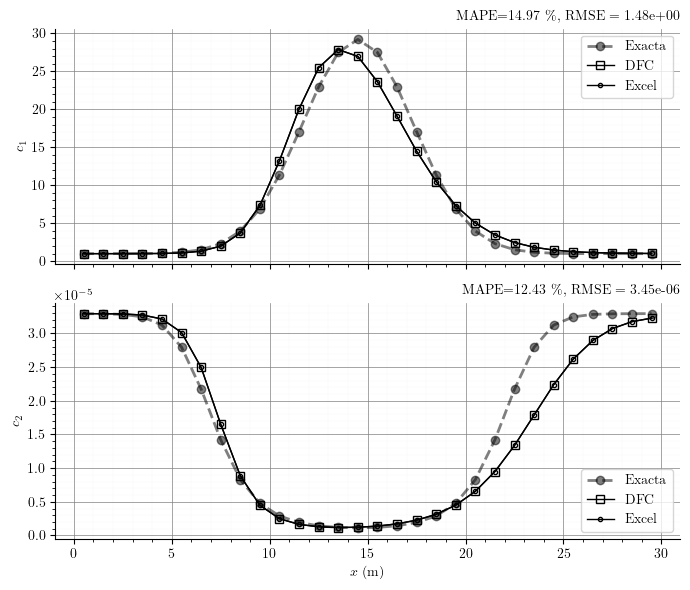

In [18]:
# --- Visualización de los resultados
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7,6))
#
# Gráfica de la especie c1
ax[0].plot(x, an_c1, "o--", c = "black", lw=2.0, alpha=0.5, label="Exacta", zorder=4)
ax[0].plot(x, c_final[0], "s-", c = "black", mec = "black", mfc="None", lw = 1.0, label="DFC", zorder=5)
ax[0].plot(x, c1_excel, ".-", c = "black", mec = "black", mfc="None", lw = 1.0,label="Excel", zorder=5)
ax[0].set_title(rf"MAPE={MAPE1:5.2f} \%, RMSE = {RMSE1:5.2e}", fontsize=10, loc="right")
ax[0].set_ylabel("$c_1$")
ax[0].minorticks_on()
ax[0].grid(True, which='minor', color='gainsboro', lw = 0.05, zorder=2)
ax[0].grid(True,which='major', color='gray', lw = 0.5, zorder=3)
ax[0].legend()
ax[0].spines.right.set_visible(False)
ax[0].spines.top.set_visible(False)
#
# Gráfica de la especie c2
ax[1].plot(x, an_c2, "o--", c = "black", lw=2.0, alpha=0.5, label="Exacta", zorder=4)
ax[1].plot(x, c_final[1], "s-", c = "black", mec = "black", mfc="None", lw = 1.0, label="DFC", zorder=5)
ax[1].plot(x, c2_excel, ".-", c = "black", mec = "black", mfc="None", lw = 1.0, label="Excel", zorder=5)
ax[1].set_title(rf"MAPE={MAPE2:5.2f} \%, RMSE = {RMSE2:5.2e}", fontsize=10, loc="right")
ax[1].set_xlabel("$x$ (m)")
ax[1].set_ylabel("$c_2$")
ax[1].minorticks_on()
ax[1].grid(True, which='minor', color='gainsboro', lw = 0.05, zorder=2)
ax[1].grid(True,which='major', color='gray', lw = 0.5, zorder=3)
ax[1].legend(loc="lower right")
ax[1].spines.right.set_visible(False)
ax[1].spines.top.set_visible(False)

plt.tight_layout()
#plt.savefig("yeso.pdf")
plt.show()